
# ML Project: Payment Default Risk Prediction

This notebook presents a complete Machine Learning pipeline to predict payment default risk using historical customer data.

---

##  Objective

Build a supervised classification model that predicts the **risk bucket** of a customer (e.g. no delay, early, medium, late, etc.) based on features such as purchase price, monthly payment, age, city, and vehicle information.

---


In [1]:

# Step 1: Import required libraries
import pandas as pd
import numpy as np
import os

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib



# Load Excel dataset from your local path
file_path = r"C:\Users\hardr\OneDrive\Pictures\Datos adjuntos\Documents\Desktop\Python_scripts\ML_RIESGO_IMPAGO\src\data_sample\CAR4CASH_DATA.xlsx"
df = pd.read_excel(file_path)

# Show first rows
df.head()


In [2]:

# Load Excel dataset (assumes file is saved locally in this path)
file_path = r"C:\Users\hardr\OneDrive\Pictures\Datos adjuntos\Documents\Desktop\Python_scripts\ML_RIESGO_IMPAGO\src\data_sample\CAR4CASH_DATA.xlsx"
df = pd.read_excel(file_path)

# Show first rows
df.head()


,ID,Tipo,Representante comercial,Precio de compra,Moneda,IVA,Precio de compra en €,Firma del contrato,Fecha del principio de contrato,Plazo mensual,...,Matrícula,F. de matriculación:,Kilómetros recorridos,Número de propietarios anteriores,Fecha de la última matriculación del vehículo,Importaciones del extranjero,Fecha de importación del extranjero,Vendido a tercero,Condición,Partner
0,7246,Contrato,"Car Service Partner Spain, S.L.",2795,EUR,0 % IVA,70350.15,Sí,2025-04-09,189,...,2143HZB,2014-08-29 00:00:00,181649,6,NaN,0,NaN,0000-00-00,Activos,google
1,7245,Contrato,"Car Service Partner Spain, S.L.",2795,EUR,0 % IVA,70350.15,Sí,2025-04-08,189,...,8581MVC,2014-05-21 00:00:00,205000,1,NaN,1,2024-09-19,0000-00-00,Activos,Web
2,7244,Contrato,"Car Service Partner Spain, S.L.",2295,EUR,0 % IVA,57765.15,Sí,2025-04-08,156,...,0511MCD,2011-05-30 00:00:00,206500,2,2024-09-02,1,2022-11-07,0000-00-00,Activos,google
3,7243,Contrato,"Car Service Partner Spain, S.L.",2295,EUR,0 % IVA,57765.15,Sí,2025-04-08,170,...,7900HFJ,2011-07-08 00:00:00,60895,4,2025-04-07,0,NaN,0000-00-00,Activos,google
4,7240,Contrato,"Car Service Partner Spain, S.L.",4295,EUR,0 % IVA,108105.15,Sí,2025-04-07,295,...,9381KWN,2019-04-29 00:00:00,166000,0,2019-04-29,0,NaN,0000-00-00,Activos,google


## Step 3: Clean column names

In [3]:

# Remove trailing spaces in column names
df.columns = df.columns.str.strip()


## Step 4: Create target variable 'Bucket'

In [6]:

def asignar_bucket(v):
    if pd.isna(v):
        return 'desconocido'
    try:
        v = int(v)
        if v >= 0:
            return 'no delay'
        elif v >= -5:
            return 'early'
        elif v >= -15:
            return 'medium'
        elif v >= -30:
            return 'late'
        elif v >= -60:
            return 'external'
        else:
            return 'realdebt'
    except:
        return 'desconocido'

df['Bucket'] = df['Vencimiento'].apply(asignar_bucket)
df = df[df['Bucket'] != 'desconocido']


## Step 5: Define features (X) and target (y)

In [7]:

X = df.drop(columns=['Vencimiento', 'Bucket'])
y = df['Bucket']


## Step 6: Preprocessing - Handle missing values and types

In [8]:

cat_features = ['Código postal', 'Ciudad', 'Marca', 'Modelo', 'Partner', 'Genero']
num_features = ['Precio de compra en €', 'Plazo mensual', 'edad']

# Convert categorical to string and fill missing
for col in cat_features:
    X[col] = X[col].fillna("missing").astype(str)

# Convert numeric to float and coerce invalid values to NaN
for col in num_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Check for missing values
print("Missing values per column:")
print(X.isnull().sum())


Missing values per column:
ID                                                   0
Tipo                                                 0
Representante comercial                              0
Precio de compra                                     0
Moneda                                               0
IVA                                                  0
Precio de compra en €                                0
Firma del contrato                                   0
Fecha del principio de contrato                      0
Plazo mensual                                        0
Plazo del IVA                                        0
Cantidad de tasa de reserva en € IVA incluido        0
Cantidad de tasa de reserva en € sin IVA             0
Fecha del plazo siguiente                           37
Precio de mercado                                    0
Cociente precio de mercado/precio de compra (%)      0
Teléfono                                             0
Correo electrónico                    

## Step 7: Create complete preprocessing + modeling pipeline

In [9]:

# Define numeric and categorical pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])


## Step 8: Train-test split and improved model setup

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])


## Step 9: Train and evaluate the model

In [11]:

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       early       0.00      0.00      0.00         6
    external       0.00      0.00      0.00        10
        late       0.00      0.00      0.00         9
      medium       0.00      0.00      0.00         6
    no delay       0.53      0.84      0.65        87
    realdebt       0.59      0.40      0.47        68

    accuracy                           0.54       186
   macro avg       0.19      0.21      0.19       186
weighted avg       0.46      0.54      0.48       186

Confusion Matrix:
[[ 0  0  0  0  4  2]
 [ 0  0  0  0  8  2]
 [ 0  0  0  0  7  2]
 [ 0  0  0  0  6  0]
 [ 0  1  0  0 73 13]
 [ 0  0  1  0 40 27]]


c:\Users\hardr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hardr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hardr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## Step 10: Save the trained model

In [12]:

# Create models directory if it doesn't exist
os.makedirs("src/models", exist_ok=True)

# Save the model
joblib.dump(pipeline, "src/models/modelo_riesgo_impago.pkl")
print("Model saved at: src/models/modelo_riesgo_impago.pkl")


Model saved at: src/models/modelo_riesgo_impago.pkl



## Recomendaciones de uso del modelo entrenado / Using the trained model with new data

### 🇪🇸 Español

Para utilizar este modelo entrenado con datos nuevos, es importante seguir algunas recomendaciones clave:

1. El dataset debe contener **exactamente las mismas columnas de entrada** que se usaron durante el entrenamiento:
   - `'Código postal'`
   - `'Ciudad'`
   - `'Marca'`
   - `'Modelo'`
   - `'Partner'`
   - `'Genero'`
   - `'Precio de compra en €'`
   - `'Plazo mensual'`
   - `'edad'`

2. **No debe incluir la columna `'Bucket'`**, ya que es la variable objetivo que el modelo va a predecir.

3. No hace falta escalar, codificar ni imputar datos manualmente: el modelo ya incluye todo el preprocesamiento necesario.

4. Para predecir, solo tienes que hacer:

```python
from joblib import load
modelo = load("src/models/modelo_riesgo_impago.pkl")
predicciones = modelo.predict(nuevos_datos)
```

---

### 🇬🇧 English

To use the trained model with new data, please follow these guidelines:

1. Your input data must include **exactly the same columns** used during training:
   - `'Código postal'` (Postal code)
   - `'Ciudad'` (City)
   - `'Marca'` (Car brand)
   - `'Modelo'` (Car model)
   - `'Partner'` (Partner)
   - `'Genero'` (Gender)
   - `'Precio de compra en €'` (Purchase price)
   - `'Plazo mensual'` (Monthly payment)
   - `'edad'` (Age)

2. **Do not include the `'Bucket'` column** — that is the value to be predicted.

3. There is no need to scale or encode manually: the model includes all required preprocessing.

4. Example usage:

```python
from joblib import load
model = load("src/models/modelo_riesgo_impago.pkl")
predictions = model.predict(new_data)
```



##  EDA - Exploratory Data Analysis

En esta sección analizamos gráficamente algunas características clave del dataset original para entender mejor el comportamiento de los clientes.

In this section, we visually analyze key features from the original dataset to better understand customer behavior.


In [13]:

import matplotlib.pyplot as plt
import seaborn as sns

# Ajustes de estilo
sns.set(style="whitegrid")


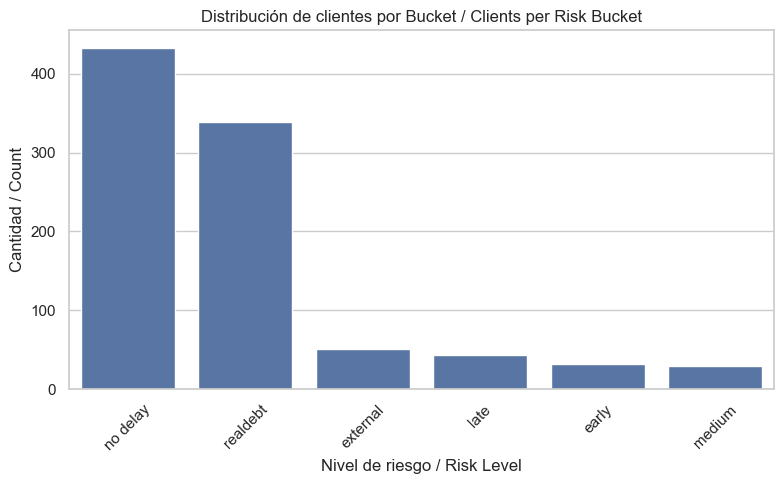

In [14]:

# 🇪🇸 Distribución de niveles de riesgo
# 🇬🇧 Distribution of risk levels

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Bucket', order=df['Bucket'].value_counts().index)
plt.title("Distribución de clientes por Bucket / Clients per Risk Bucket")
plt.xlabel("Nivel de riesgo / Risk Level")
plt.ylabel("Cantidad / Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


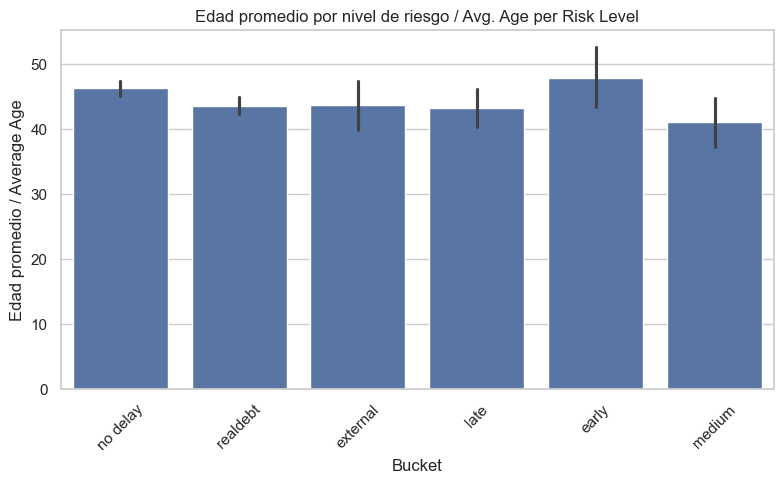

In [15]:

# 🇪🇸 Edad promedio por Bucket
# 🇬🇧 Average age by Bucket

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Bucket', y='edad', estimator='mean', order=df['Bucket'].value_counts().index)
plt.title("Edad promedio por nivel de riesgo / Avg. Age per Risk Level")
plt.xlabel("Bucket")
plt.ylabel("Edad promedio / Average Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


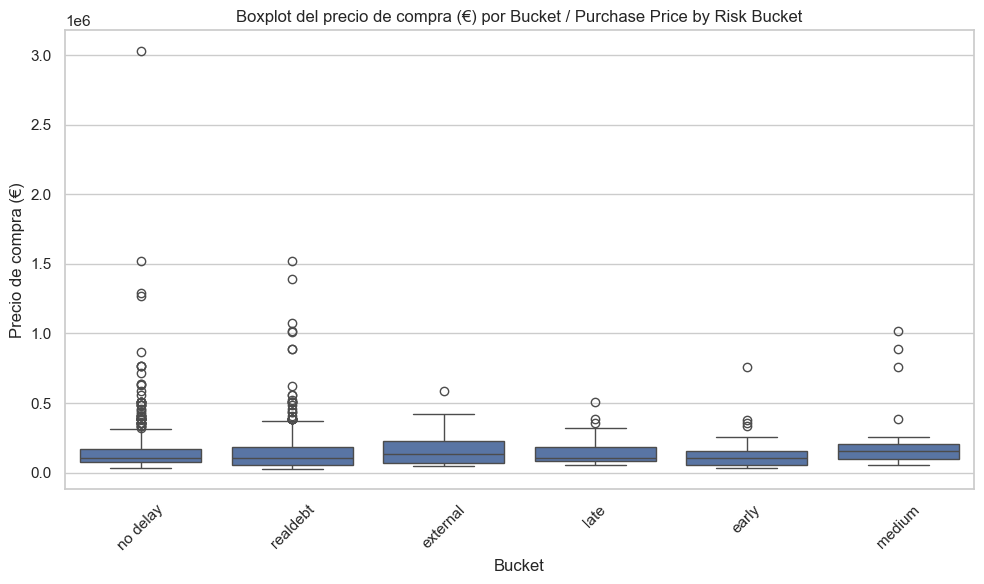

In [16]:

# 🇪🇸 Distribución del precio de compra por Bucket
# 🇬🇧 Distribution of purchase price by Bucket

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Bucket', y='Precio de compra en €', order=df['Bucket'].value_counts().index)
plt.title("Boxplot del precio de compra (€) por Bucket / Purchase Price by Risk Bucket")
plt.xlabel("Bucket")
plt.ylabel("Precio de compra (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


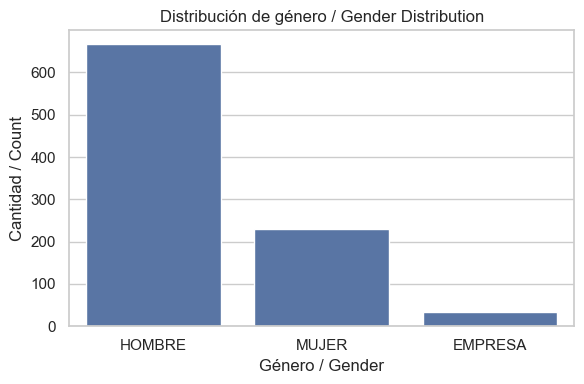

In [17]:

# 🇪🇸 Conteo por género
# 🇬🇧 Gender distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Genero', order=df['Genero'].value_counts().index)
plt.title("Distribución de género / Gender Distribution")
plt.xlabel("Género / Gender")
plt.ylabel("Cantidad / Count")
plt.tight_layout()
plt.show()
